Scopul proiectului este de a utiliza **algoritmul k-NN** pentru a clasifica angajații în funcție de nivelul salariului (low, medium, high), pe baza caracteristicilor precum experiența, educația, domeniul de activitate și alte atribute relevante.

Ideea de baza a fost impartirea salariilor în 3 clase: low medium high

și să prezicem în ce categorie se încadrează un exemplu nou.

**IMPORTURI**

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nalisha/job-salary-prediction-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'job-salary-prediction-dataset' dataset.
Path to dataset files: /kaggle/input/job-salary-prediction-dataset


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [4]:
import os

print(os.listdir(path))

['job_salary_prediction_dataset.csv']


In [5]:
df = pd.read_csv(path + "/job_salary_prediction_dataset.csv")  #dataframe

**Vizualizarea unori informatii importante cu privire la dataset ul încarcat**

In [6]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [7]:
# verificare valori lipsă
print(df.isnull().sum())

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64


Eliminarea valorilor nule (daca exista)

In [8]:
df = df.dropna() # NaN not a number

**Coloana de "Salary" o vom transforma in clase**

Vom utiliza **funcția qcut** pentru a împărți valorile salariului în trei intervale egale (low, medium, high) pe baza cuantilelor și va returna pragurile numerice (bins) care delimitează aceste clase.

In [9]:
df["salary_class"] = pd.qcut(df["salary"], q=3, labels=["low", "medium", "high"])

In [10]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary,salary_class
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413,low
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764,low
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123,medium
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123,high
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069,high


In [11]:
_, bins = pd.qcut(df["salary"], q=3, retbins=True)
print(bins)

[ 31867. 127849. 159802. 333046.]


low	    31,867 → 127,849

medium	127,849 → 159,802

high	  159,802 → 333,046

**Eliminam coloana initiala de "Salary"**

In [12]:
df = df.drop("salary", axis=1)

In [13]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary_class
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,low
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,low
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,medium
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,high
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,high


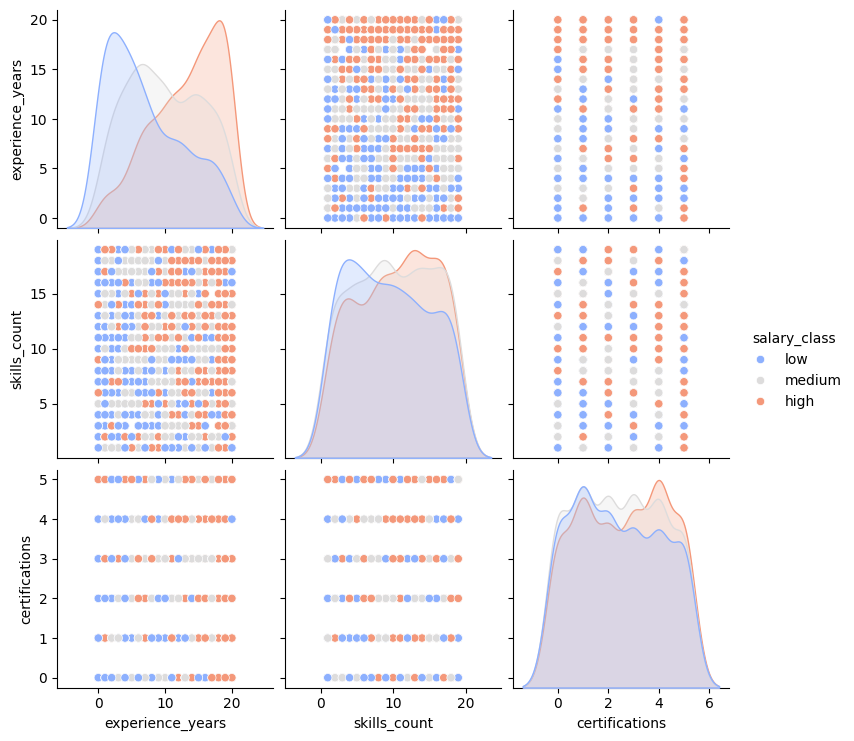

In [15]:
df_sample = df.sample(2000, random_state=42)  # ia 2000 de rânduri aleatorii

# Pairplot: vizualizare relații între variabile numerice colorate după clase
sns.pairplot(df_sample, hue='salary_class', palette='coolwarm')
plt.show()

**Encoding pentru date categorice**
**Transformă text → numere**

În acest pas, se separă variabila țintă (salary_class) de caracteristicile de intrare, iar variabilele categoriale sunt transformate în format numeric prin one-hot encoding, în timp ce etichetele țintă sunt codificate numeric pentru a putea fi utilizate de algoritmul k-NN.

In [16]:
# Target
y = df["salary_class"]

# Features
X = df.drop("salary_class", axis=1)

# One-hot encoding pentru coloanele categorice
X = pd.get_dummies(X, drop_first=True)

# Encode target
y = LabelEncoder().fit_transform(y)

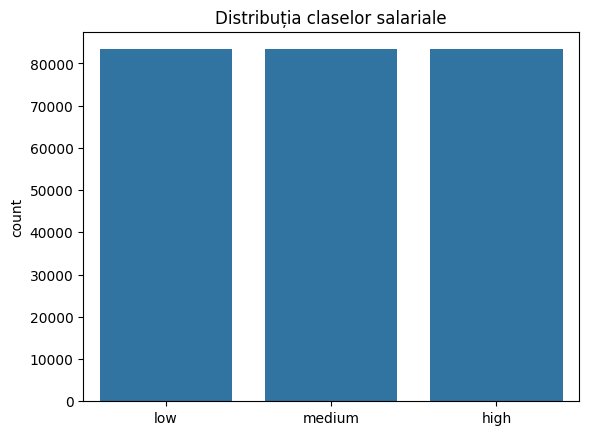

In [17]:
sns.countplot(x=y)
plt.xticks([0,1,2], ["low", "medium", "high"])
plt.title("Distribuția claselor salariale")
plt.show()

**Împărțirea datelor în train/test**

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Datasetul are 250,000 de randuri, dar dupa split:

X_train: 200,000 rânduri (features pentru antrenare)

X_test: 50,000 rânduri (features pentru test)

y_train: 200,000 rânduri (target pentru antrenare)

y_test: 50,000 rânduri (target pentru test)

In [19]:
scaler = StandardScaler() #important pentru k-NN, pentru că distanțele depind de magnitudine

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

media = 0

deviația standard = 1

**Antrenare - folosind fit()**

**Testare - folosind predict()**

In [20]:
k_values = range(1, 20)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k, n_jobs=-1) # n_neighbors=k → spune modelului câți vecini să folosească pentru predicție.
                                                           # n_jobs=-1 → folosește toate procesoarele disponibile pt a accelera calculul distanțelor
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)       #Pt fiecare punct din X_test:
                                         #Se calculeaza distanaa fata de toate punctele din X_train.
                                         #Se selecteaza cei mai apropiati k vecini.
                                         #Se ia majoritatea etichetelor vecinilor => predicția pentru acel punct.

    acc = accuracy_score(y_test, y_pred) # Compară predictiile (y_pred) cu etichetele reale (y_test) și calculează procentul de predicții corecte
    accuracies.append(acc)              # salvează acuratețea pentru k curent
    print(f"k={k}, accuracy={acc}")

k=1, accuracy=0.7077
k=2, accuracy=0.68804
k=3, accuracy=0.699
k=4, accuracy=0.71518
k=5, accuracy=0.6969
k=6, accuracy=0.71418
k=7, accuracy=0.70692
k=8, accuracy=0.71226
k=9, accuracy=0.71238
k=10, accuracy=0.72122
k=11, accuracy=0.71508
k=12, accuracy=0.72452
k=13, accuracy=0.72182
k=14, accuracy=0.7233
k=15, accuracy=0.72276
k=16, accuracy=0.72534
k=17, accuracy=0.72354
k=18, accuracy=0.72562
k=19, accuracy=0.72508


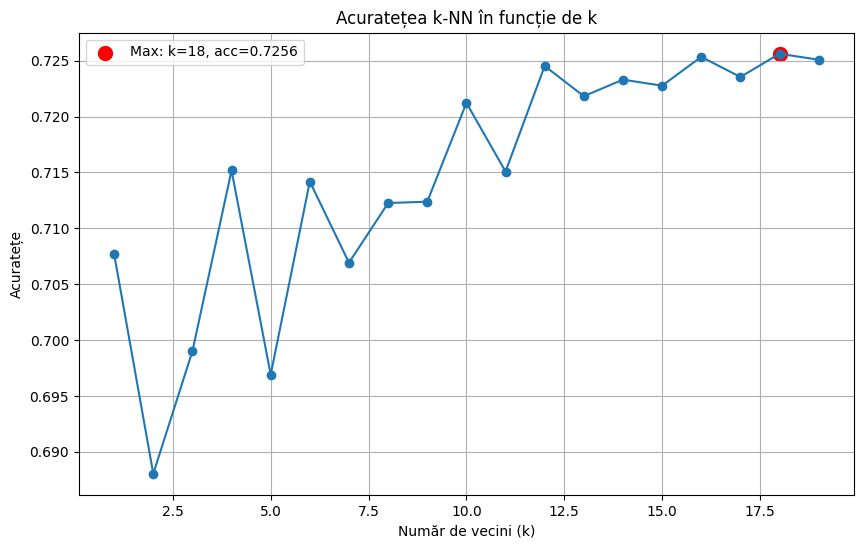

Acuratețea maximă 0.7256 se obține la k=18


In [21]:
# Grafic cu acuratețea în funcție de k
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o')
plt.xlabel("Număr de vecini (k)")
plt.ylabel("Acuratețe")
plt.title("Acuratețea k-NN în funcție de k")
plt.grid(True)

# Găsim valoarea maximă și k corespunzător
max_acc = max(accuracies)
best_k = k_values[accuracies.index(max_acc)]

# Marcam punctul de acuratețe maximă pe grafic
plt.scatter(best_k, max_acc, color='red', s=100, label=f"Max: k={best_k}, acc={max_acc:.4f}")
plt.legend()
plt.show()

print(f"Acuratețea maximă {max_acc:.4f} se obține la k={best_k}")

In [22]:
best_k = k_values[np.argmax(accuracies)]
print("Cel mai bun k:", best_k)

Cel mai bun k: 18


**Precision** - Din toate punctele pe care modelul le-a spus „low”, câte chiar erau low

**Recall**- Din toate punctele care erau „low” în realitate, câte a găsit modelul

**F1-score** - O combinație între precision și recall (media lor echilibrată)

**Support** - Câte exemple reale există din acea clasă în setul de test

In [23]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=["low", "medium", "high"]))

              precision    recall  f1-score   support

         low       0.75      0.84      0.79     16685
      medium       0.81      0.79      0.80     16560
        high       0.61      0.55      0.58     16755

    accuracy                           0.73     50000
   macro avg       0.72      0.73      0.72     50000
weighted avg       0.72      0.73      0.72     50000



Aleg sa folosesc k 18, desi pentru setui foarte mari, cum este acesta, k poate lua valori de pana la 400.

In [24]:
model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy final:", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy final: 0.72562
Confusion matrix:
 [[13982   136  2567]
 [  251 13111  3198]
 [ 4566  3001  9188]]


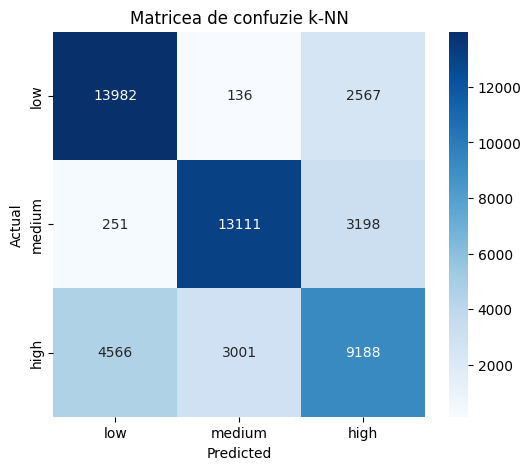

In [25]:

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["low","medium","high"],
            yticklabels=["low","medium","high"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Matricea de confuzie k-NN")
plt.show()

In [26]:

comparison = pd.DataFrame({'Real': y_test, 'Predicted': y_pred})
print(comparison.head(20))  # primele 10 exemple

    Real  Predicted
0      0          0
1      1          1
2      1          1
3      0          0
4      1          1
5      0          0
6      1          2
7      1          1
8      1          1
9      0          0
10     1          1
11     0          0
12     1          2
13     1          1
14     0          0
15     2          2
16     0          0
17     2          2
18     2          2
19     0          0
